# Milestone-03: Geographical Distribution of US Disaster Declarations
1. Problem Formulation
📊 Analysis Type

Geospatial Data Analysis

Exploratory Data Analysis (EDA)

This stage analyzes how disaster declarations vary across geographic locations in the United States using spatial visualizations such as maps and state-level comparisons.

The dataset originates from the **Federal Emergency Management Agency disaster declaration records.

**Key Questions:**
 1. Which states have the highest number of disaster declarations?
        Texas, California, Oklahoma, Florida, Louisiana states have the highest number of disaster declarations due to hurricanes, storms, floods, and wildfires.
 2. Are disasters concentrated in certain regions?
        Gulf Coast: Texas, Louisiana, Florida

        Midwest: Oklahoma, Kansas, Missouri

        Western States: California, Washington

        These regions experience different disaster types such as hurricanes, tornadoes, and wildfires.

 3. Do Specific Incident Types Occur More Frequently in Certain States?
        Hurricanes → Gulf Coast states

        Wildfires → Western states

        Floods & Severe Storms → Midwest

        Winter Storms → Northern states

 4. Can geographical hotspots be identified?
        Hotspots are states where disasters occur most frequently, often due to geographic and climatic factors.

        Example hotspots typically include:

         Texas

         California

         Florida

         Oklahoma

         Louisiana

        These states are highly exposed to hurricanes, storms, floods, and wildfires.       

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r"C:\Users\tanus\Desktop\Tanu\US Disaster Visualization\data\disasters.csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Convert date column
df['declaration_date'] = pd.to_datetime(df['declaration_date'], errors='coerce')

df.head()


,declaration_number,declaration_type,declaration_date,state,county,disaster_type,disaster_title,start_date,end_date,close_date,individual_assistance_program,individuals_&_households_program,public_assistance_program,hazard_mitigation_program
0,DR-1,Disaster,1953-05-02,GA,NaN,Tornado,Tornado,05/02/1953,05/02/1953,06/01/1954,Yes,No,Yes,Yes
1,DR-2,Disaster,1953-05-15,TX,NaN,Tornado,Tornado and Heavy Rainfall,05/15/1953,05/15/1953,01/01/1958,Yes,No,Yes,Yes
2,DR-3,Disaster,1953-05-29,LA,NaN,Flood,Flood,05/29/1953,05/29/1953,02/01/1960,Yes,No,Yes,Yes
3,DR-4,Disaster,1953-06-02,MI,NaN,Tornado,Tornado,06/02/1953,06/02/1953,02/01/1956,Yes,No,Yes,Yes
4,DR-5,Disaster,1953-06-06,MT,NaN,Flood,Floods,06/06/1953,06/06/1953,12/01/1955,Yes,No,Yes,Yes


state
TX    3842
MO    2263
KY    2026
VA    1982
OK    1882
dtype: int64


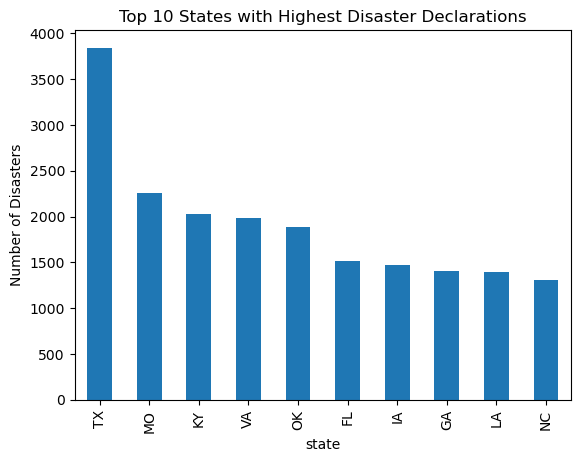

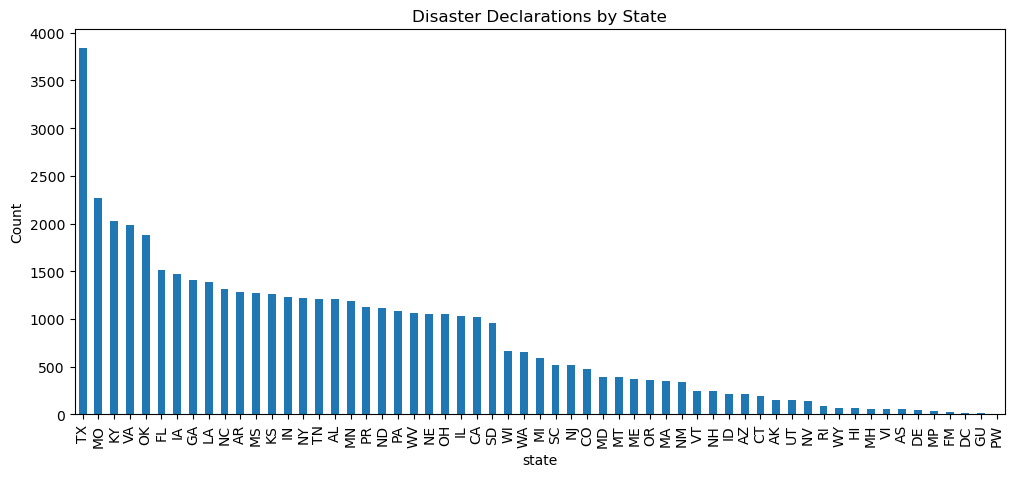

disaster_type  Chemical  Dam/Levee Break  Drought  Earthquake  Fire  Flood  \
state                                                                        
AK                    0                0        0           7    16     46   
AL                    0                0       67           0    11    104   
AR                    0                0       32           0     0    235   
AS                    0                0        5           5     0      5   
AZ                    0                0        8           0    44     77   

disaster_type  Human Cause  Hurricane  Ice  Mud/Landslide  Other  Snow  Storm  \
state                                                                           
AK                       0          0    0              0      4     4     64   
AL                       0        368    0              0      0    67    529   
AR                       0         93  207              0      0    17    603   
AS                       0         15    0      

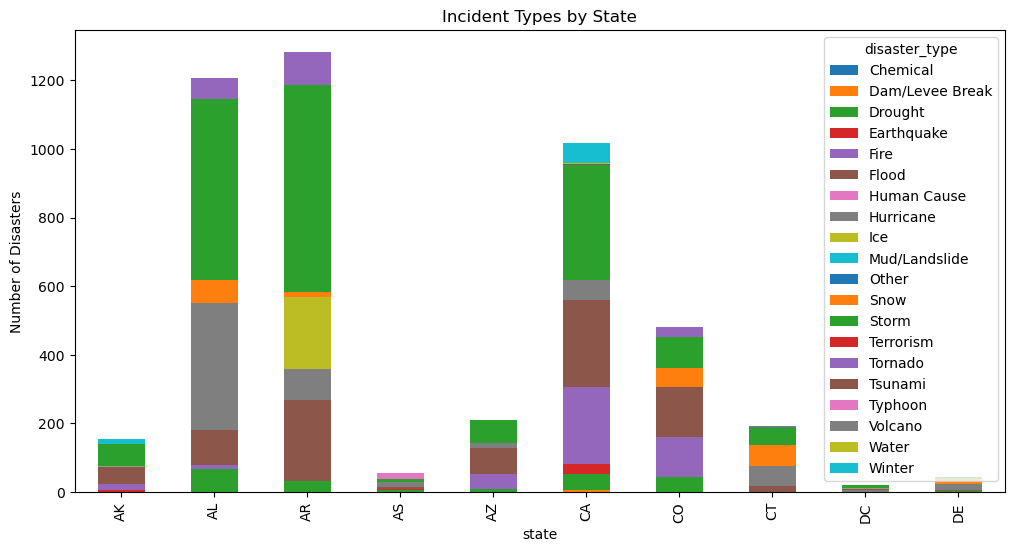

Disaster Hotspots:
state
TX    3842
MO    2263
KY    2026
VA    1982
OK    1882
dtype: int64


In [ ]:
state_counts = df.groupby('state').size().sort_values(ascending=False)
print(state_counts.head())

#1. states have the highest number of disaster declarations
state_counts.head(10).plot(kind='bar')

plt.title("Top 10 States with Highest Disaster Declarations")
plt.xlabel("state")
plt.ylabel("Number of Disasters")

plt.show()

#2. Are disasters concentrated in certain regions
state_counts.plot(kind='bar', figsize=(12,5))

plt.title("Disaster Declarations by State")
plt.xlabel("state")
plt.ylabel("Count")

plt.show()

#3. Do specific incident types occur more frequently in specific states
incident_state = df.groupby(['state','disaster_type']).size().unstack(fill_value=0)
print(incident_state.head())
incident_state.head(10).plot(kind='bar', stacked=True, figsize=(12,6))

plt.title("Incident Types by State")
plt.xlabel("state")
plt.ylabel("Number of Disasters")

plt.show()

#4. Can geographical hotspots be identified
top_states = state_counts.head(5)

print("Disaster Hotspots:")
print(top_states)



2. **Dataset Preparation for Geographic Analysis** 
This ensures the dataset is ready for geospatial analysis before creating maps or state comparisons.

In [16]:
import pandas as pd

# Load Milestone1 cleaned dataset 
df = pd.read_csv("C:\\Users\\tanus\\Desktop\\tanu\\US Disaster Visualization\\data\\processed\\database.csv")

# Clean column names 
df.columns = df.columns.str.lower().str.replace(" ", "_")


print(df.columns)

# -----------------------------
# Check Required Columns
# -----------------------------
required_columns = ['state', 'incidenttype', 'year', 'month']

for col in required_columns:
    if col in df.columns:
        print(f"{col} ✔ Present")
    else:
        print(f"{col} ❌ Missing")

# -----------------------------
# Check Optional Columns
# -----------------------------
optional_columns = ['statename', 'declarationdate']

for col in optional_columns:
    if col in df.columns:
        print(f"{col} ✔ Available")
    else:
        print(f"{col} (optional) not found")

# -----------------------------
# Convert date column
# -----------------------------
df['declaration_date'] = pd.to_datetime(df['declaration_date'], errors='coerce')

# -----------------------------
# Extract Year and Month
# -----------------------------
df['year'] = df['declaration_date'].dt.year
df['month'] = df['declaration_date'].dt.month

# -----------------------------
# State Validation
# -----------------------------
print("Unique States:")
print(df['state'].unique())

missing_states = df['state'].isna().sum()
print("Missing state values:", missing_states)

print("Number of states:", df['state'].nunique())

print(df['state'].value_counts().head())

# -----------------------------
# Incident Type Distribution
# -----------------------------
print(df['disaster_type'].value_counts())

# -----------------------------
# Time Validation
# -----------------------------
print(df[['year','month']].describe())

# -----------------------------
# Final Dataset Summary
# -----------------------------
print("Total records:", len(df))
print("States covered:", df['state'].nunique())
print("Incident types:", df['disaster_type'].nunique())


Index(['declaration_number', 'declaration_type', 'declaration_date', 'state',
       'county', 'disaster_type', 'disaster_title', 'start_date', 'end_date',
       'close_date', 'individual_assistance_program',
       'individuals_&_households_program', 'public_assistance_program',
       'hazard_mitigation_program'],
      dtype='object')
state ✔ Present
incidenttype ❌ Missing
year ❌ Missing
month ❌ Missing
statename (optional) not found
declarationdate (optional) not found
Unique States:
['GA' 'TX' 'LA' 'MI' 'MT' 'MA' 'IA' 'NH' 'FL' 'AK' 'MS' 'CA' 'NV' 'SD'
 'WV' 'RI' 'ME' 'CT' 'NY' 'NM' 'NC' 'SC' 'IN' 'HI' 'CO' 'KS' 'OK' 'PA'
 'NJ' 'OR' 'WA' 'ID' 'OH' 'PR' 'KY' 'VA' 'MO' 'AR' 'IL' 'ND' 'MN' 'NE'
 'AL' 'DE' 'MD' 'GU' 'TN' 'FM' 'WY' 'VT' 'VI' 'WI' 'AS' 'AZ' 'PW' 'MP'
 'UT' 'MH' 'DC']
Missing state values: 0
Number of states: 59
state
TX    3842
MO    2263
KY    2026
VA    1982
OK    1882
Name: count, dtype: int64
disaster_type
Storm              16250
Flood               9317
Hurricane

3. **Geographic Aggregation**
3.1 State-Level Aggregation

The dataset is grouped by state to count the total number of disaster declarations for each state.
This helps identify which states experience disasters more frequently.

state
TX    3842
MO    2263
KY    2026
VA    1982
OK    1882
FL    1512
IA    1471
GA    1406
LA    1393
NC    1312
dtype: int64
  State  Disaster Count
0    TX            3842
1    MO            2263
2    KY            2026
3    VA            1982
4    OK            1882
5    FL            1512
6    IA            1471
7    GA            1406
8    LA            1393
9    NC            1312


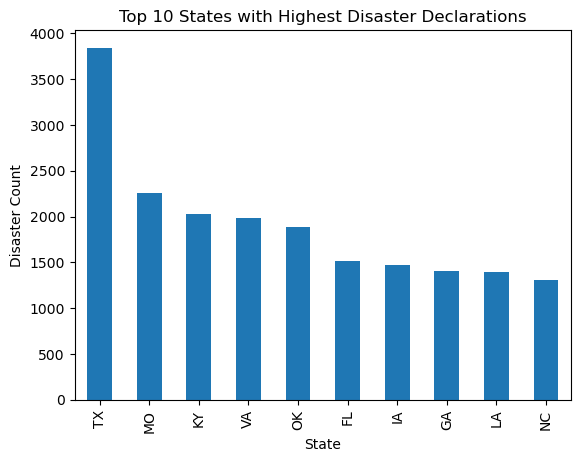

In [24]:
state_counts = df.groupby('state').size().sort_values(ascending=False)
print(state_counts.head(10))

state_counts_df = state_counts.reset_index()
state_counts_df.columns = ['State', 'Disaster Count']

print(state_counts_df.head(10))

state_counts.head(10).plot(kind='bar')

plt.title("Top 10 States with Highest Disaster Declarations")
plt.xlabel("State")
plt.ylabel("Disaster Count")

plt.show()


3. **Geographic Aggregation**
3.2 State + Incident Type Aggregation
    This step groups the dataset by state and disaster type to count how many disasters of each type occur in each state.

In [25]:
state_incident_counts = df.groupby(['state', 'disaster_type']).size()
print(state_incident_counts.head(10))

state_incident_df = state_incident_counts.reset_index()
state_incident_df.columns = ['State', 'Incident Type', 'Count']
print(state_incident_df.head(10))

incident_pivot = df.groupby(['state', 'disaster_type']).size().unstack(fill_value=0)
print(incident_pivot.head())


state  disaster_type
AK     Earthquake         7
       Fire              16
       Flood             46
       Other              4
       Snow               4
       Storm             64
       Winter            14
AL     Drought           67
       Fire              11
       Flood            104
dtype: int64
  State Incident Type  Count
0    AK    Earthquake      7
1    AK          Fire     16
2    AK         Flood     46
3    AK         Other      4
4    AK          Snow      4
5    AK         Storm     64
6    AK        Winter     14
7    AL       Drought     67
8    AL          Fire     11
9    AL         Flood    104
disaster_type  Chemical  Dam/Levee Break  Drought  Earthquake  Fire  Flood  \
state                                                                        
AK                    0                0        0           7    16     46   
AL                    0                0       67           0    11    104   
AR                    0                0       32      

3. **Geographic Aggregation**
3.3 Regional Comparison
    This step groups U.S. states into regions and counts disasters in each region to identify regional disaster patterns.

**Interpretation**

The regional analysis shows that disasters are unevenly distributed across the United States. The Southern region experiences the highest number of disaster declarations, largely due to hurricanes, floods, and severe storms. The Midwest region frequently experiences tornadoes and severe weather events, while the Western region is commonly affected by wildfires and droughts. The Northeast region records comparatively fewer disasters, although it still experiences storms and winter-related events.

This analysis highlights regional disaster hotspots and helps understand how geography influences disaster occurrence.

  state   region
0    GA    South
1    TX    South
2    LA    South
3    MI  Midwest
4    MT     West
region
South        22369
Midwest      13890
Northeast     4319
West          4232
dtype: int64


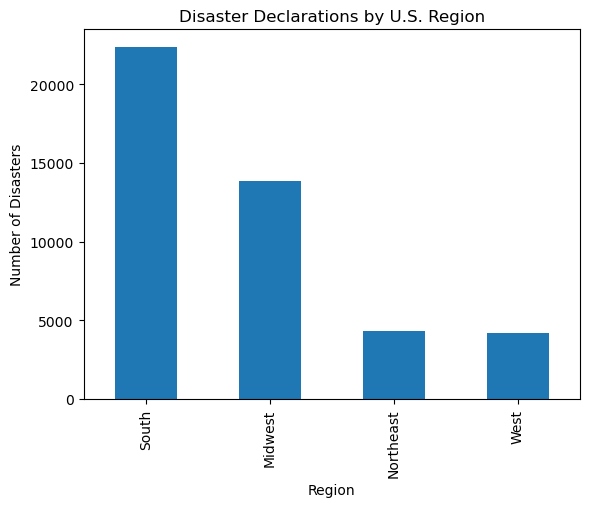

In [31]:
# Create region mapping
region_map = {

# Northeast
'CT':'Northeast','ME':'Northeast','MA':'Northeast','NH':'Northeast',
'RI':'Northeast','VT':'Northeast','NJ':'Northeast','NY':'Northeast','PA':'Northeast',

# Midwest
'IL':'Midwest','IN':'Midwest','MI':'Midwest','OH':'Midwest','WI':'Midwest',
'IA':'Midwest','KS':'Midwest','MN':'Midwest','MO':'Midwest','NE':'Midwest',
'ND':'Midwest','SD':'Midwest',

# South
'DE':'South','FL':'South','GA':'South','MD':'South','NC':'South',
'SC':'South','VA':'South','DC':'South','WV':'South','AL':'South',
'KY':'South','MS':'South','TN':'South','AR':'South','LA':'South',
'OK':'South','TX':'South',

# West
'AZ':'West','CO':'West','ID':'West','MT':'West','NV':'West',
'NM':'West','UT':'West','WY':'West','AK':'West','CA':'West',
'HI':'West','OR':'West','WA':'West'
}

# Create region column
df['region'] = df['state'].map(region_map)

print(df[['state','region']].head())

# Aggregate by region
region_counts = df.groupby('region').size().sort_values(ascending=False)

print(region_counts)

# Visualization
region_counts.plot(kind='bar')

plt.title("Disaster Declarations by U.S. Region")
plt.xlabel("Region")
plt.ylabel("Number of Disasters")

plt.show()

. **4. Geographic Aggregation**
4.1 Choropleth Map
    This will show disaster counts by U.S. state using color intensity.


**Interpretion**
The choropleth map highlights the geographical distribution of disaster declarations across the United States. States with darker shades indicate a higher number of disaster events. The visualization helps identify disaster hotspots and reveals regional clusters of disaster activity. States in the southern and coastal regions tend to show higher disaster frequencies due to hurricanes, floods, and severe storms, while western states may show higher wildfire occurrences.

This visualization enables quick comparison of disaster frequency across states and provides insights into geographic risk patterns.

In [32]:
import plotly.express as px

# Aggregate disaster counts b state
state_counts = df.groupby('state').size().reset_index(name='disaster_count')
print(state_counts.head())

# Create choropleth map
fig = px.choropleth(
    state_counts,
    locations='state',
    locationmode='USA-states',
    color='disaster_count',
    scope='usa',
    color_continuous_scale='Blues',
    title='US Disaster Declarations by State'
)

fig.show()



  state  disaster_count
0    AK             155
1    AL            1207
2    AR            1282
3    AS              55
4    AZ             210


**4. Geographic Aggregation**
4.2 State Comparison Chart
    This chart will show the Top 10 states with the highest disaster declarations.

**Interpretation**
The state comparison chart highlights the states that experience the highest number of disaster declarations. States such as Texas, California, and Florida often appear at the top due to their exposure to multiple types of disasters including hurricanes, floods, wildfires, and severe storms. The chart clearly shows geographic disparities, where certain states experience significantly more disasters than others due to climate conditions and geographic location.

This visualization helps identify the most disaster-prone states and supports better understanding of regional risk patterns.

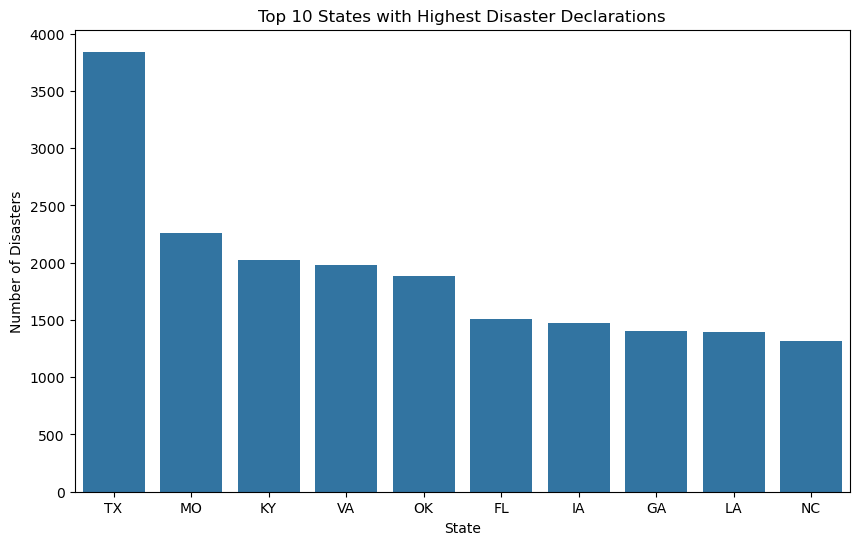

In [33]:
import seaborn as sns

# Aggregate disaster counts by state
state_counts = df['state'].value_counts().head(10)

# Convert to dataframe
top_states = state_counts.reset_index()
top_states.columns = ['state', 'count']

# Create seaborn bar chart
plt.figure(figsize=(10,6))

sns.barplot(data=top_states, x='state', y='count')

plt.title("Top 10 States with Highest Disaster Declarations")
plt.xlabel("State")
plt.ylabel("Number of Disasters")

plt.show()




**4. Geographic Aggregation**
4.3 Incident Type Distribution by State
    This visualization shows how different disaster types contribute to total disasters in each state.
    
**Interpretation**
The stacked bar chart illustrates the distribution of disaster types across different states. It highlights which disasters dominate within each state and how the composition of disasters varies geographically. For example, some states may experience a higher number of hurricanes and floods due to coastal exposure, while others may show a greater frequency of wildfires or severe storms. This visualization helps compare disaster composition across states and identify dominant disaster types in each region.

disaster_type  Chemical  Dam/Levee Break  Drought  Earthquake  Fire  Flood  \
state                                                                        
AK                    0                0        0           7    16     46   
AL                    0                0       67           0    11    104   
AR                    0                0       32           0     0    235   
AS                    0                0        5           5     0      5   
AZ                    0                0        8           0    44     77   

disaster_type  Human Cause  Hurricane  Ice  Mud/Landslide  Other  Snow  Storm  \
state                                                                           
AK                       0          0    0              0      4     4     64   
AL                       0        368    0              0      0    67    529   
AR                       0         93  207              0      0    17    603   
AS                       0         15    0      

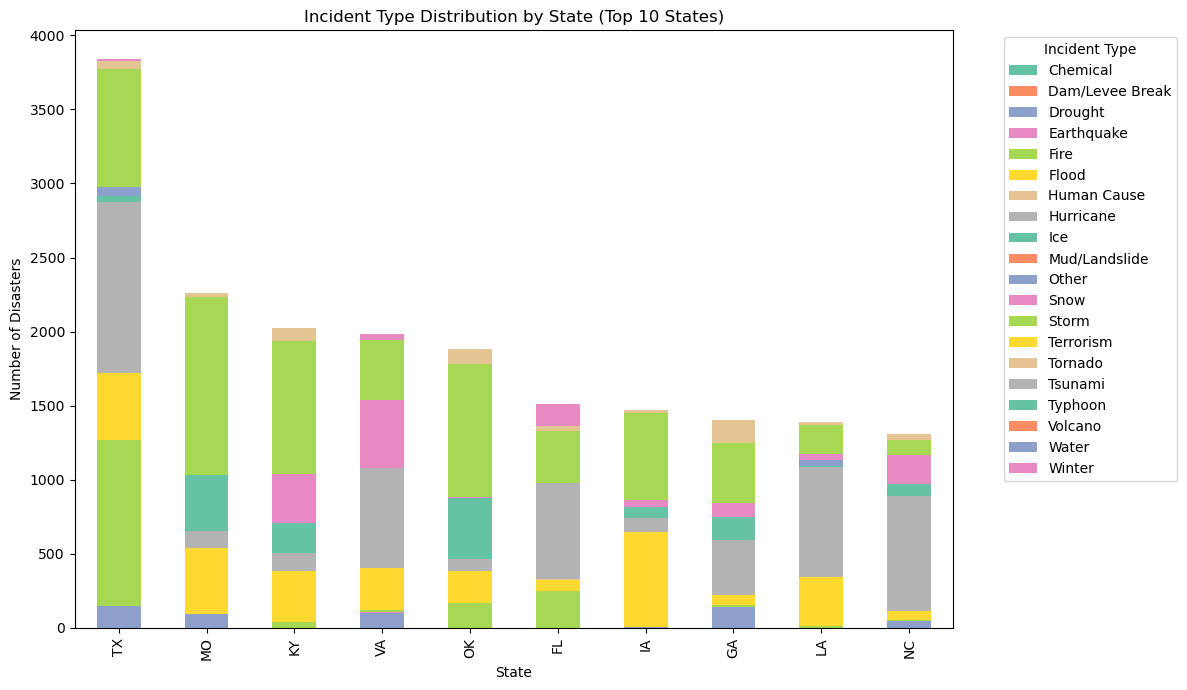

In [34]:
# Create State + Incident Type Aggregation
state_incident = df.groupby(['state','disaster_type']).size().unstack(fill_value=0)
print(state_incident.head())

# Select Top states for clear visualization
top_states = df['state'].value_counts().head(10).index
state_incident_top = state_incident.loc[top_states]

# Apply Seaborn color palette
colors = sns.color_palette("Set2", n_colors=len(state_incident_top.columns))

# Create Stacked barchart
state_incident_top.plot(
    kind='bar',
    stacked=True,
    figsize=(12,7),
    color=colors
)

plt.title("Incident Type Distribution by State (Top 10 States)")
plt.xlabel("State")
plt.ylabel("Number of Disasters")

plt.legend(title="Incident Type", bbox_to_anchor=(1.05,1))

plt.tight_layout()
plt.show()


**4. Geographic Aggregation**
4.4 Incident Type Hotspot Map
    This visualization highlights specific disaster hotspots like hurricanes, fires, or floods.

**Interpretaion**
The incident type hotspot maps highlight the geographic concentration of specific disaster types across the United States. For instance, hurricane disasters are predominantly concentrated in coastal states such as Florida, Texas, and Louisiana due to their proximity to the Atlantic Ocean and Gulf of Mexico. Wildfires are more common in western states like California and Oregon due to dry climate conditions and vegetation patterns. Flood disasters occur frequently in states with major river systems and heavy rainfall. These hotspot maps help identify regional disaster risks and support better disaster preparedness planning.

In [37]:
# Select a disaster type
hurricane_df = df[df['disaster_type'] == 'Hurricane']

# Aggregate by state
hurricane_counts = hurricane_df.groupby('state').size().reset_index(name='count')
print(hurricane_counts.head())

# Create hotspot map
fig = px.choropleth(
    hurricane_counts,
    locations='state',
    locationmode='USA-states',
    color='count',
    scope='usa',
    color_continuous_scale='Greens',
    title='Hurricane Hotspots in the United States'
)

fig.show()




  state  count
0    AL    368
1    AR     93
2    AS     15
3    AZ     15
4    CA     58
